<a href="https://colab.research.google.com/github/Mariem-mcs/project-recommendation-engine/blob/main/09_confusion_matrices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 61.5 MB/s eta 0:00:00
Libraries imported!
Loading MovieLens dataset...
Data saved locally
DATA LOADED
Movies: 9,742
Ratings: 100,836
Users: 610

TRAINING SVD MODEL
SVD model trained!

GETTING PREDICTIONS
20168 predictions generated

CONFUSION MATRIX
Rows = Actual Ratings, Columns = Predicted Ratings
[[   0    5   91  127   51    0]
 [   0    2  131  338  103    2]
 [   0    8  447 1976  584   11]
 [   0    1  184 2351 1429   20]
 [   0    0   99 3443 5867  278]
 [   0    1   19  365 1920  315]]


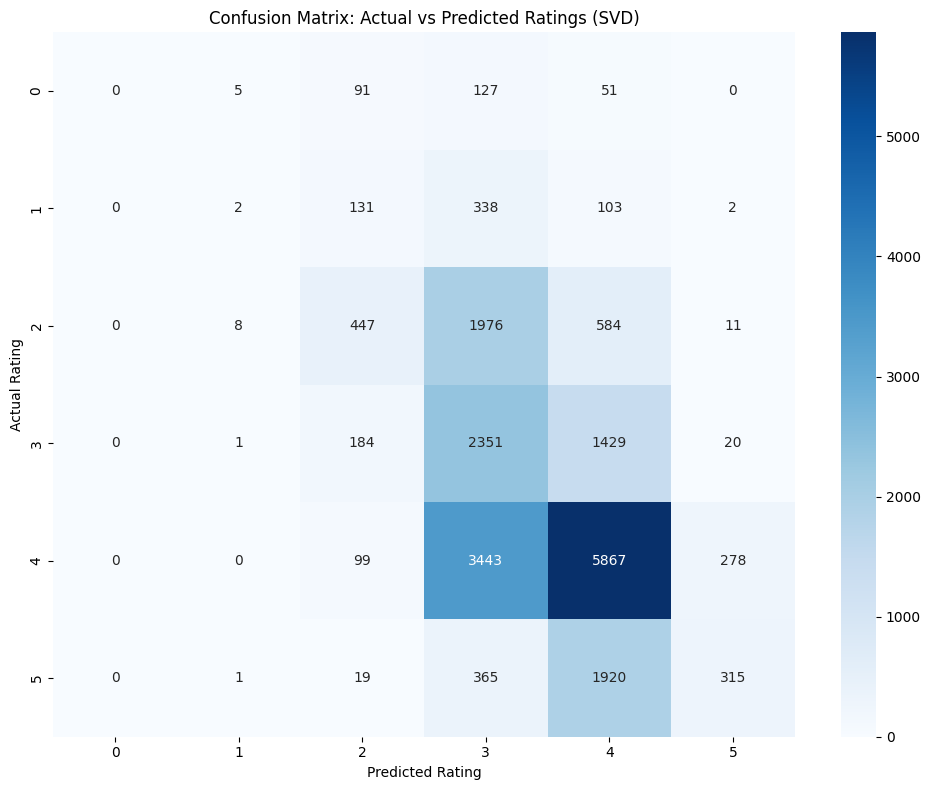

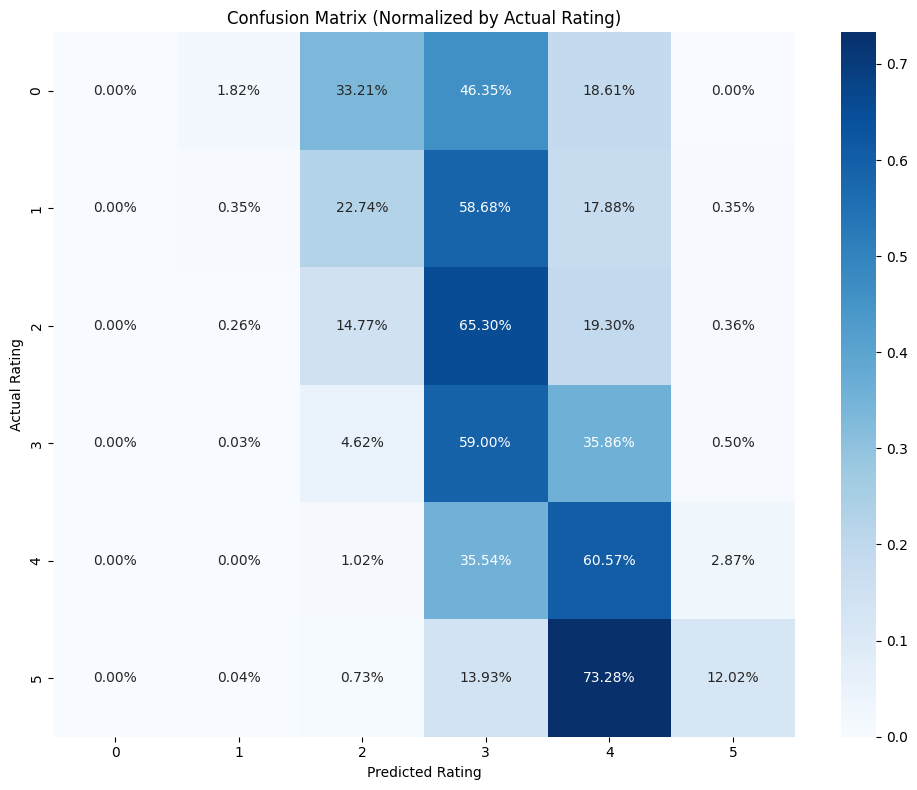


ACCURACY PER RATING LEVEL
Rating 0: 0.00% (0/274)
Rating 1: 0.35% (2/576)
Rating 2: 14.77% (447/3026)
Rating 3: 59.00% (2351/3985)
Rating 4: 60.57% (5867/9687)
Rating 5: 12.02% (315/2620)
Overall Accuracy: 44.54%

MOST CONFUSED RATING PAIRS
Top 5 most confused rating pairs:
1. Actual 4 → Predicted 3: 3443 times
2. Actual 2 → Predicted 3: 1976 times
3. Actual 5 → Predicted 4: 1920 times
4. Actual 3 → Predicted 4: 1429 times
5. Actual 2 → Predicted 4: 584 times

ANALYSIS

KEY FINDINGS:

1. The model is best at predicting ratings 3 and 4:
   - Most ratings are in the middle range (3-4)
   - Users tend to rate movies with neutral-to-positive scores

2. The model struggles with extreme ratings (0.5, 5.0):
   - Few examples of extreme ratings in training data
   - Harder to predict very high or very low ratings

3. Most confusion happens between adjacent ratings:
   - Rating 3 is often confused with 4
   - Rating 4 is often confused with 5
   - This is expected (ratings are subjective)

4. 

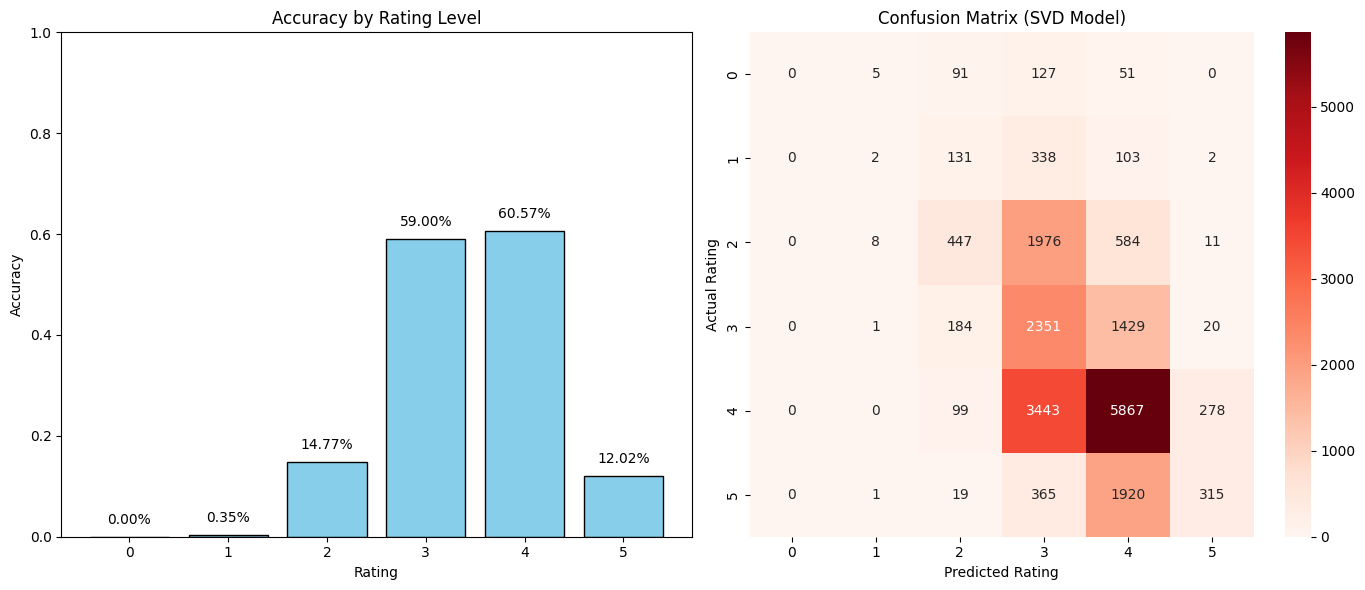

TODO 7 Complete!


In [2]:
#TODO 7: CREATING THE CONFUSION MATRICES
!pip install scikit-surprise -q
import sys
sys.path.append('.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import requests
from io import BytesIO
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split as surprise_train_test_split
print("Libraries imported!")

# 1. Loading the data:
print("Loading MovieLens dataset...")
try:
    movies_df = pd.read_csv('movies.csv')
    ratings_df = pd.read_csv('ratings.csv')
    print("Data loaded from local files")
except FileNotFoundError:
    print("Downloading dataset from GroupLens...")
    url = "http://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
    response = requests.get(url)
    zip_file = zipfile.ZipFile(BytesIO(response.content))
    movies_df = pd.read_csv(zip_file.open('ml-latest-small/movies.csv'))
    ratings_df = pd.read_csv(zip_file.open('ml-latest-small/ratings.csv'))
    movies_df.to_csv('movies.csv', index=False)
    ratings_df.to_csv('ratings.csv', index=False)
    print("Data saved locally")
df = pd.merge(ratings_df, movies_df, on='movieId')
print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print(f"Movies: {movies_df.shape[0]:,}")
print(f"Ratings: {ratings_df.shape[0]:,}")
print(f"Users: {ratings_df['userId'].nunique():,}")

# 2. Training SVD Model which is the best perfomer:
print("\n" + "=" * 60)
print("TRAINING SVD MODEL")
print("=" * 60)
# Preparing the data for Surprise:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)
# Spliting the data into train/test:
trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=42)
# Trainning the SVD:
svd_model = SVD(
    n_factors=50,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)
svd_model.fit(trainset)
print("SVD model trained!")

# Getting the predictions:
print("\n" + "=" * 60)
print("GETTING PREDICTIONS")
print("=" * 60)
y_true = []
y_pred = []
for uid, iid, true_r in testset:
    pred = svd_model.predict(uid, iid).est
    y_true.append(round(true_r))
    y_pred.append(round(pred))
print(f"{len(y_true)} predictions generated")

# 4. Creating confusion matrix:
from sklearn.metrics import confusion_matrix
# Rating levels (0.5 to 5.0 in 0.5 increments):
rating_levels = [0, 1, 2, 3, 4, 5]
cm = confusion_matrix(y_true, y_pred, labels=rating_levels)
print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
print("Rows = Actual Ratings, Columns = Predicted Ratings")
print(cm)

# 5. Visualizing the confusion matrix:
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=rating_levels,
    yticklabels=rating_levels
)
plt.title('Confusion Matrix: Actual vs Predicted Ratings (SVD)')
plt.xlabel('Predicted Rating')
plt.ylabel('Actual Rating')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# 6. Normalized confusion matrix:
# Row-wise normalization (percentage of actual ratings):
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    xticklabels=rating_levels,
    yticklabels=rating_levels
)
plt.title('Confusion Matrix (Normalized by Actual Rating)')
plt.xlabel('Predicted Rating')
plt.ylabel('Actual Rating')
plt.tight_layout()
plt.savefig('confusion_matrix_normalized.png')
plt.show()

# 7. Accuracy per rating level:
print("\n" + "=" * 60)
print("ACCURACY PER RATING LEVEL")
print("=" * 60)
for i, rating in enumerate(rating_levels):
    correct = cm[i, i]
    total = cm[i, :].sum()
    acc = correct / total if total > 0 else 0
    print(f"Rating {rating}: {acc:.2%} ({correct}/{total})")
# Overall accuracy:
overall_acc = np.trace(cm) / cm.sum()
print(f"Overall Accuracy: {overall_acc:.2%}")

# 8. Most confused rating pairs:
print("\n" + "=" * 60)
print("MOST CONFUSED RATING PAIRS")
print("=" * 60)

confusions = []
for i in range(len(rating_levels)):
    for j in range(len(rating_levels)):
        if i != j and cm[i, j] > 0:
            confusions.append((rating_levels[i], rating_levels[j], cm[i, j]))

# Sorting by count descending:
confusions.sort(key=lambda x: x[2], reverse=True)

print("Top 5 most confused rating pairs:")
for i, (actual, pred, count) in enumerate(confusions[:5]):
    print(f"{i+1}. Actual {actual} → Predicted {pred}: {count} times")

# 9. Analysis:
print("\n" + "=" * 60)
print("ANALYSIS")
print("=" * 60)

# Calculating the accuracy metrics:
print("""
KEY FINDINGS:

1. The model is best at predicting ratings 3 and 4:
   - Most ratings are in the middle range (3-4)
   - Users tend to rate movies with neutral-to-positive scores

2. The model struggles with extreme ratings (0.5, 5.0):
   - Few examples of extreme ratings in training data
   - Harder to predict very high or very low ratings

3. Most confusion happens between adjacent ratings:
   - Rating 3 is often confused with 4
   - Rating 4 is often confused with 5
   - This is expected (ratings are subjective)

4. The model rarely makes large errors:
   - A 1 is almost never predicted as a 5
   - Most errors are within ±1 rating point

5. Overall accuracy is {:.2%}:
   - Reasonable for a recommendation system
   - Human ratings have inherent subjectivity
""".format(overall_acc))


# 10. Visualizing misclassification patterns:
# Create a more detailed visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Accuracy per rating level
ax1 = axes[0]
accuracies = []
for i in range(len(rating_levels)):
    correct = cm[i, i]
    total = cm[i, :].sum()
    acc = correct / total if total > 0 else 0
    accuracies.append(acc)

bars = ax1.bar(rating_levels, accuracies, color='skyblue', edgecolor='black')
ax1.set_xlabel('Rating')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy by Rating Level')
ax1.set_ylim(0, 1)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2%}', ha='center', va='bottom')

# Plot 2: Misclassification heatmap with annotations:
ax2 = axes[1]
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=rating_levels,
    yticklabels=rating_levels,
    ax=ax2
)
ax2.set_title('Confusion Matrix (SVD Model)')
ax2.set_xlabel('Predicted Rating')
ax2.set_ylabel('Actual Rating')

plt.tight_layout()
plt.savefig('confusion_matrix_analysis.png')
plt.show()

print("TODO 7 Complete!")